# **Modeling Retinal Ganglion Cell Spiking with Generalized Linear Models Including Spike-History Effects**

# 1. Data loading and first exploration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import statsmodels.api as sm

Data from [Uzzell & Chichilnisky, 2004](http://jn.physiology.org/content/92/2/780.long)

**Dataset description — Retinal responses to white noise**

The dataset contains recordings of retinal ganglion cell activity during the presentation
of a temporally varying white-noise stimulus. It includes three main files:

1. Stim.mat
   → 'stim' contains the stimulus value (e.g., pixel intensity) for each frame of the movie.
     Each entry corresponds to one time step in the experiment.

2. stimtimes.mat
   → 'stimtimes' provides the exact time (in seconds) of each frame, sampled at 120 Hz.
     This allows mapping between frame index and real experiment time.

3. SpTimes.mat
   → 'SpTimes' is a list of arrays, each containing the spike times of one recorded neuron.
     Spike times are expressed in units of stimulus frames (i.e., when each spike occurred
     relative to the visual stimulus).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
datadir='/content/drive/MyDrive/BrainModelling_20252026/brain_modeling_20_10_2025/encoding/data_RGCs'

In [ ]:
# Load row data
stim = np.squeeze(loadmat(f'{datadir}/Stim.mat')['Stim']) # contains stimulus value at each frame
stim_times = np.squeeze(loadmat(f'{datadir}/stimtimes.mat')['stimtimes']) # contains time in seconds at each frame (120 Hz)
all_spike_times = [np.squeeze(x) for x in np.squeeze(loadmat(f'{datadir}/SpTimes.mat')['SpTimes'])] # time of spikes for 4 neurons (in units of stim frames)

print(f'Length of stimulus: {stim.shape}')
print(f'Number of spikes for each of 4 neurons: {" ".join([str(x.size) for x in all_spike_times])}')

Length of stimulus: (144051,)
Number of spikes for each of 4 neurons: 31528 21553 49954 43126


In [ ]:
# Select only the third cell
cell_idx = 2
spike_times = all_spike_times[cell_idx]

In [ ]:
# Print out some basic info
dt_stim = stim_times[1] - stim_times[0] # time bin size
refresh_rate = 1/dt_stim # refresh rate of the monitor
num_time_bins = stim.size # number of time bins in stimulus
num_spikes = spike_times.size # number of spikes

print(f'Loaded RGC data: cell {cell_idx}')
print(f'Number of stim frames: {num_time_bins} ({num_time_bins*dt_stim:.1f} minutes)')
print(f'Time bin size: {dt_stim*1000:.1f} ms')
print(f'Number of spikes: {num_spikes} (mean rate={num_spikes/num_time_bins*refresh_rate:.1f} Hz)')

Loaded RGC data: cell 2
Number of stim frames: 144051 (1201.5 minutes)
Time bin size: 8.3 ms
Number of spikes: 49954 (mean rate=41.6 Hz)


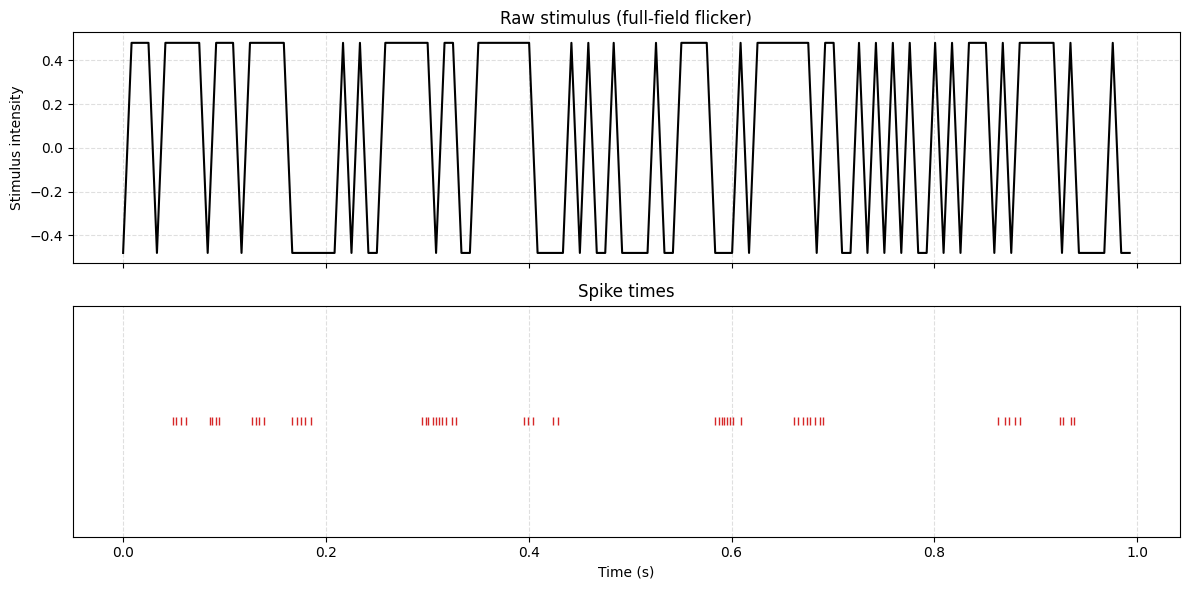

In [ ]:
# Raw data basic visualization
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

iiplot = np.arange(120)
ttplot = iiplot * dt_stim

# --- Stimulus ---
ax1.plot(ttplot, stim[iiplot], color='k')
ax1.set_title('Raw stimulus (full-field flicker)')
ax1.set_ylabel('Stimulus intensity')
ax1.grid(True, linestyle='--', alpha=0.4)

# --- Spikes ---
spike_times_plot = spike_times[(spike_times >= ttplot[0]) & (spike_times < ttplot[-1])]
ax2.plot(spike_times_plot, np.ones_like(spike_times_plot), '|', color='tab:red')
ax2.set_title('Spike times')
ax2.set_xlabel('Time (s)')
ax2.set_yticks([])
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


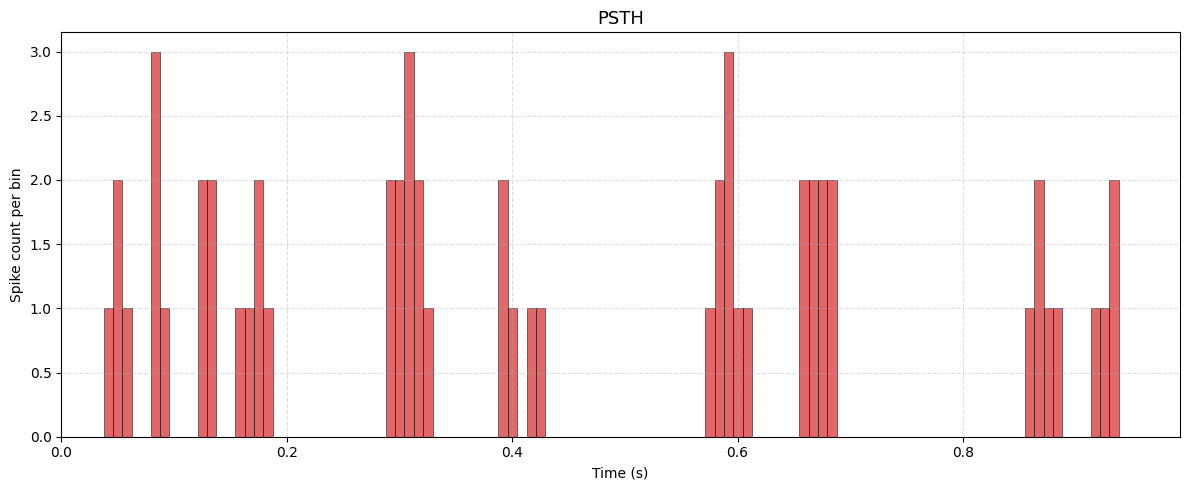

In [ ]:
spikes_bin_centers = np.arange(num_time_bins+1) * dt_stim
spikes_binned, _ = np.histogram(spike_times, spikes_bin_centers)


plt.figure(figsize=(12,5))

# Create bar plot of binned spike counts (PSTH)
plt.bar(ttplot, spikes_binned[iiplot], width=dt_stim, color='tab:red', alpha=0.7, edgecolor='k', linewidth=0.5)

plt.title('PSTH', fontsize=13)
plt.xlabel('Time (s)')
plt.ylabel('Spike count per bin')
plt.xlim(ttplot[0], ttplot[-1])
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# **2. General Linear Model - Gaussian case**
## **2.1 Build the design matrix**
Before fitting the model, we need to assemble the design matrix.
This matrix contains, for each time bin of the neural response, the corresponding segment of the stimulus used to predict the spike count.
Each row therefore represents the stimulus history preceding one response bin.

<Figure size 640x480 with 0 Axes>

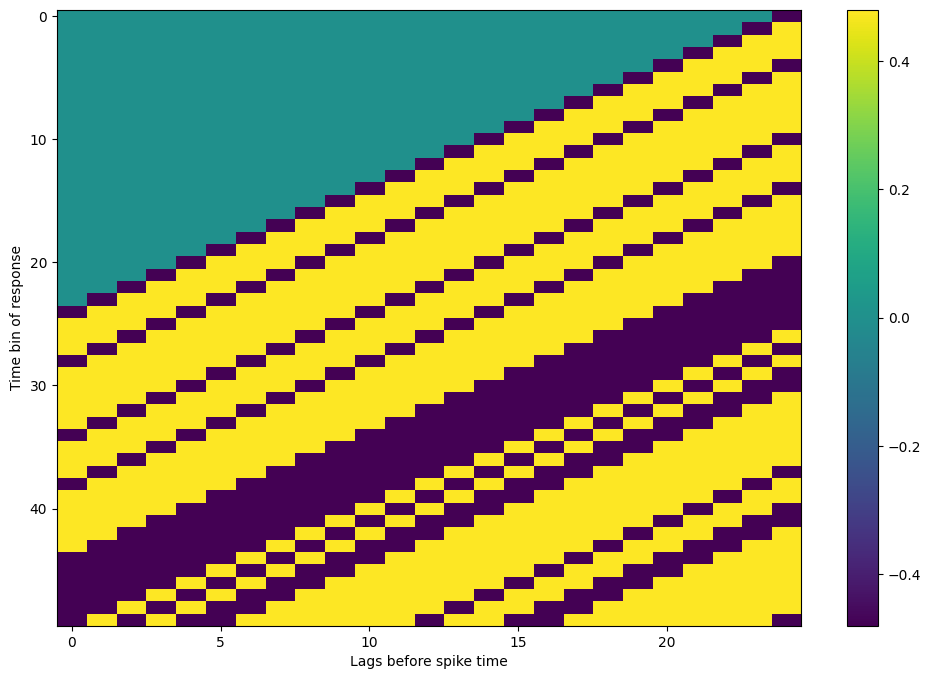

In [ ]:
# Set the number of time bins of stimulus to use for predicting spikes
ntfilt = 25

# Build the design matrix
padded_stim = np.hstack((np.zeros((ntfilt-1)), stim)) # pad early bins of stimulus with zero
design_mat = np.zeros((num_time_bins,ntfilt))
for j in np.arange(num_time_bins):
    design_mat[j] = padded_stim[j:j+ntfilt]

# Visualize a small part of the design matrix
plt.clf()
plt.figure(figsize=[12,8])
plt.imshow(design_mat[:50], aspect='auto', interpolation='nearest')
plt.xlabel('Lags before spike time')
plt.ylabel('Time bin of response')
plt.colorbar()
plt.show()

Notice it has a structure where every row is a shifted copy of the row
above, which comes from the fact that for each time bin of response, we are grabbing the preceding 'nkt' bins of stimulus as predictor.

**Test:** What if we change the number of considered time bins (ntfilt)?

##**2.2 Compute the spike-triggered average (STA)**
In many cases it's useful to visualize the STA (even if your stimuli are
not white noise), just because if we don't see any kind of structure then this may indicate that we have a problem (e.g., a mismatch between the design matrix and binned spike counts.) """
### Understanding the STA computation

The line:
    sta = (design_mat.T @ spikes_binned) / num_spikes

computes the **Spike-Triggered Average (STA)** in its compact matrix form.

---

#### A. Components

| Symbol | Variable | Meaning |
|---------|-----------|----------|
| X | `design_mat` | Stimulus matrix (n_time_bins × n_lags); each row contains the recent stimulus history for one time bin |
| Y | `spikes_binned` | Vector of spike counts for each time bin |
| N_spikes | `num_spikes` | Total number of spikes across all bins |

---

#### B. Definition of the STA

By definition, the STA is the **average stimulus preceding spikes**:

    STA = (1 / N_spikes) * Σ_t [ s(t) * y(t) ]

where:
- s(t) is the stimulus vector at time t,
- y(t) is the number of spikes (usually 0 or 1) in that bin.

Intuitively, it’s the mean of all stimulus segments that led to spikes.

---

#### C. Matrix formulation

The summation above can be written compactly as:

    Σ_t s(t) y(t) = XᵀY

Hence:

    STA = (XᵀY) / N_spikes

Here, XᵀY computes the stimulus–response correlation by weighting each
stimulus sample by the spike count at that time, and dividing by N_spikes
gives the mean.




<Figure size 640x480 with 0 Axes>

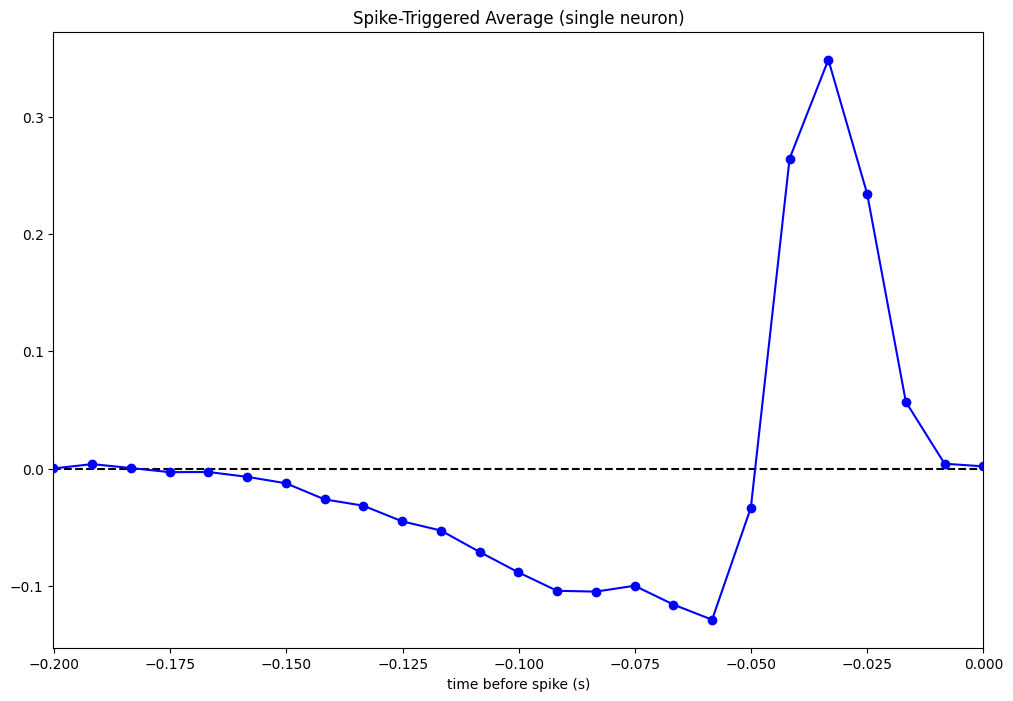

In [ ]:
# Compute the STA now that we have the design matrix
sta = (design_mat.T @ spikes_binned)/num_spikes

# Plot
ttk = np.arange(-ntfilt+1,1)*dt_stim  # time bins for STA (in seconds)
plt.clf()
plt.figure(figsize=[12,8])
plt.plot(ttk,ttk*0, 'k--')
plt.plot(ttk, sta, 'bo-')
plt.title('Spike-Triggered Average (single neuron)')
plt.xlabel('time before spike (s)')
plt.xlim([ttk[0],ttk[-1]])
plt.show()


#### D. Relation to GLM model

In a linear model of the form:

    Y = Xk + noise

we have:

    XᵀY ≈ stimulus–response correlation  (the STA)
    XᵀX ≈ stimulus autocorrelation
    k̂ = (XᵀX)⁻¹ XᵀY  → optimal linear filter

## **2.3 STA vs. Whitened STA**

- **STA (Spike-Triggered Average)**  
  Computed as:  STA = (XᵀY) / N_spikes  
  → the mean stimulus preceding spikes.  
  If the stimulus is *Gaussian white noise*, then  k̂ ≈ XᵀX  and  
  the STA gives an **unbiased estimate** of the true linear filter.

- **Whitened STA (Maximum Likelihood / Least Squares Estimate)**  
  Computed as:  k̂ = (XᵀX)⁻¹ XᵀY  
  → corrects for correlations in the stimulus.  
  When stimuli are *not white* (e.g., natural scenes), this step
  “decorrelates” the input so that correlated features do not bias the filter estimate.

- **In this dataset**  
  The stimulus is white noise (full-field flicker), so  
  XᵀX ≈ c·I and the whitened STA differs from the regular STA
  only by a scaling factor.

<Figure size 640x480 with 0 Axes>

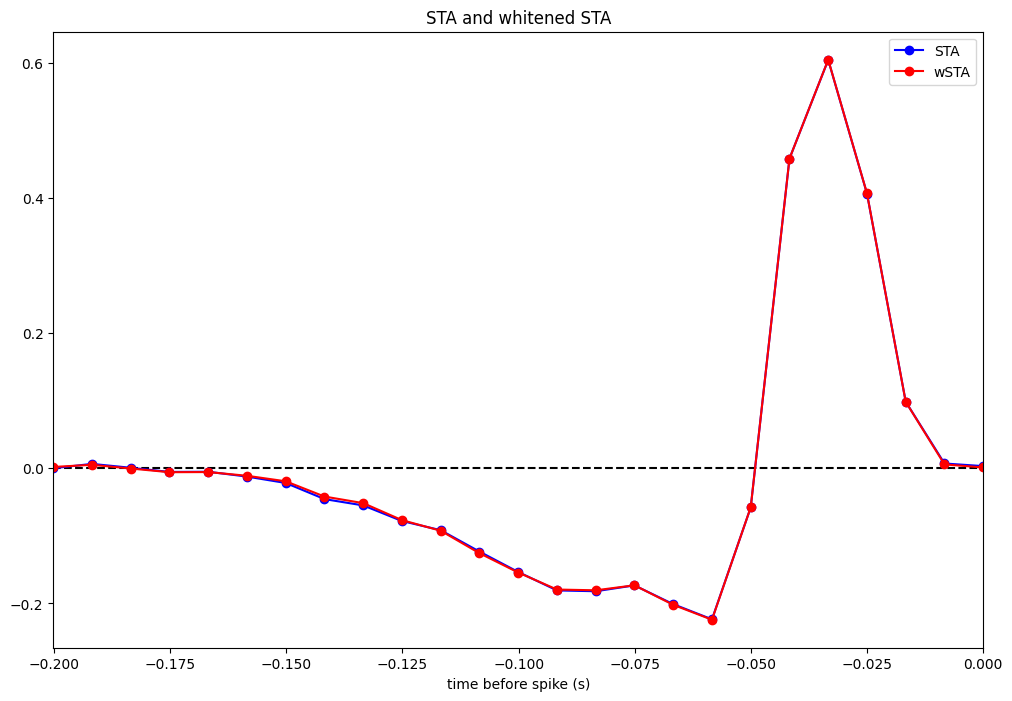

In [ ]:
from numpy.linalg import inv, norm

### whitened STA
wsta = inv(design_mat.T @ design_mat) @ sta * num_spikes

### Let's plot them both (rescaled as unit vectors so we can see differences in their shape).
plt.clf()
plt.figure(figsize=[12,8])
plt.plot(ttk,ttk*0, 'k--')
plt.plot(ttk, sta/norm(sta), 'bo-', label="STA")
plt.plot(ttk, wsta/norm(wsta), 'ro-', label="wSTA")
plt.legend()
plt.title('STA and whitened STA')
plt.xlabel('time before spike (s)')
plt.xlim([ttk[0],ttk[-1]])
plt.show()

## **2.4 Predicting spikes with a linear-Gaussian GLM**
The whitened STA can actually be used to predict spikes because it corresponds to a proper estimate of the model parameters

<Figure size 640x480 with 0 Axes>

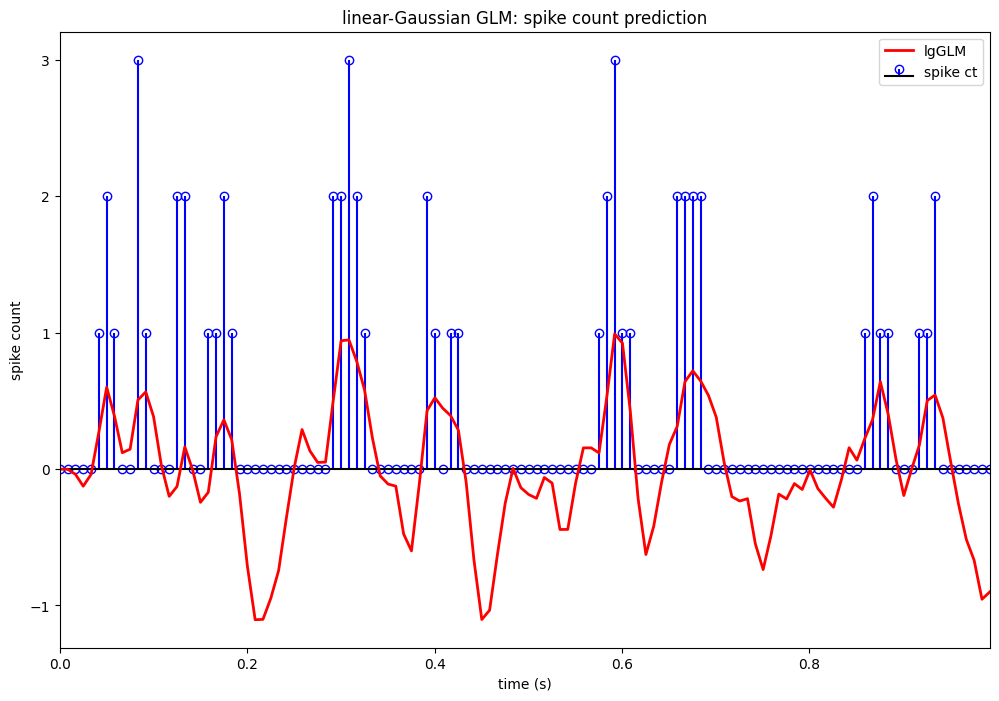

In [ ]:
sppred_lgGLM = design_mat @ wsta  # predicted spikes from linear-Gaussian GLM

# Let's see how good this "prediction" is
# (Prediction in quotes because we are looking at the performance
# on training data, not test data (not really a prediction)

#Plot real spike train and prediction
plt.clf()
plt.figure(figsize=[12,8])
markerline,_,_ = plt.stem(ttplot,spikes_binned[iiplot], linefmt='b-', basefmt='k-', label="spike ct")
plt.setp(markerline, 'markerfacecolor', 'none')
plt.setp(markerline, 'markeredgecolor', 'blue')
plt.plot(ttplot,sppred_lgGLM[iiplot], color='red', linewidth=2, label="lgGLM")
plt.title('linear-Gaussian GLM: spike count prediction')
plt.ylabel('spike count'); plt.xlabel('time (s)')
plt.xlim([ttplot[0], ttplot[-1]])
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

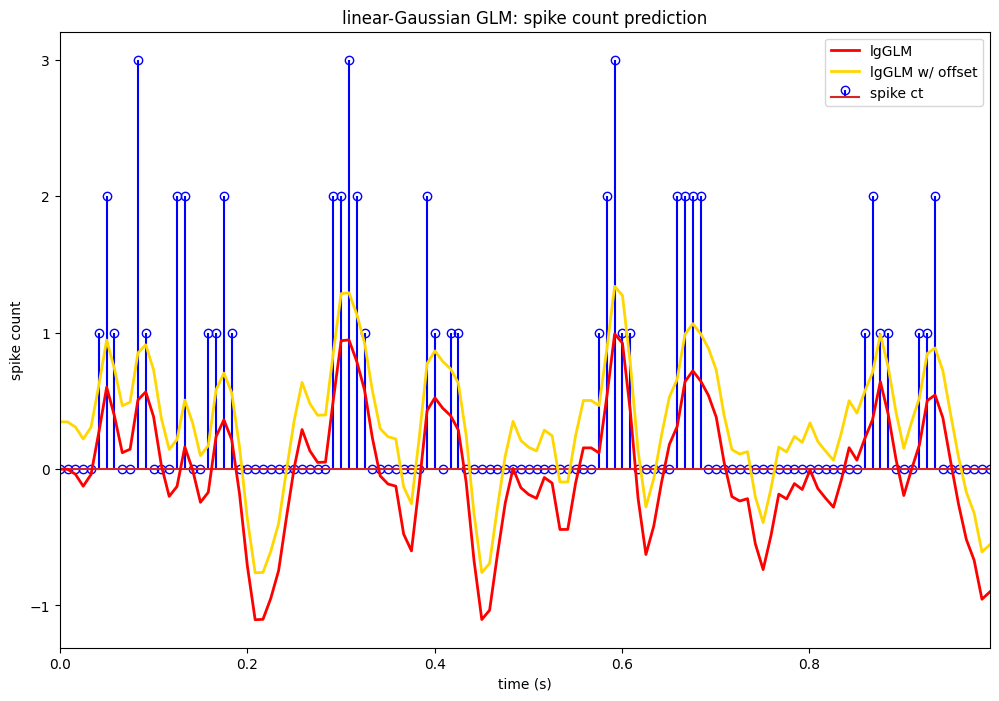

Training performances (R^2): lin-gauss GLM, no offset: 0.12
Training performances (R^2): lin-gauss GLM, w/ offset: 0.39


In [ ]:
# Add offset to the sta: we have to include an offset term in the design matrix, which will allow our prediction to have non-zero mean (since the stimulus here was normalized to have zero mean).

# Updated design matrix
design_mat_offset = np.hstack((np.ones((num_time_bins,1)), design_mat))     # just add a column of ones

# Compute again whitened STA
wsta_offset = inv(design_mat_offset.T @ design_mat_offset) @ (design_mat_offset.T @ spikes_binned)
const = wsta_offset[0]   # the additive offset
wsta_offset = wsta_offset[1:]  # linear filter part

# Redo prediction (with offset)
sppred_lgGLM_offset = const + design_mat @ wsta_offset

#Plot
plt.clf()
plt.figure(figsize=[12,8])
markerline,_,_ = plt.stem(ttplot,spikes_binned[iiplot], linefmt='b-', label="spike ct")
plt.setp(markerline, 'markerfacecolor', 'none')
plt.setp(markerline, 'markeredgecolor', 'blue')
plt.plot(ttplot,sppred_lgGLM[iiplot], color="red", linewidth=2, label = 'lgGLM')
plt.plot(ttplot,sppred_lgGLM_offset[iiplot], color="gold", linewidth=2, label = 'lgGLM w/ offset')
plt.title('linear-Gaussian GLM: spike count prediction')
plt.ylabel('spike count'); plt.xlabel('time (s)')
plt.xlim([ttplot[0], ttplot[-1]])
plt.legend()
plt.show()

### Report relevant training error (squared prediction error on
### training data)
mse1 = np.mean((spikes_binned-sppred_lgGLM)**2)   # mean squared error, GLM no offset
mse2 = np.mean((spikes_binned-sppred_lgGLM_offset)**2)  # mean squared error, with offset
rss = np.mean((spikes_binned-np.mean(spikes_binned))**2)    # squared error of spike train
print('Training performances (R^2): lin-gauss GLM, no offset: {:.2f}'.format(1-mse1/rss))
print('Training performances (R^2): lin-gauss GLM, w/ offset: {:.2f}'.format(1-mse2/rss))

# **3. Generalized Linear Model - Poisson case**

Also known as Linear–Nonlinear–Poisson model (LNP).
The LNP model is a standard framework for describing how a neuron transforms a sensory stimulus into a sequence of spikes.

1. **Linear stage**
   The stimulus is first passed through a linear filter that captures
   how the neuron integrates inputs over time:
       x_t = kᵀ s_t + b
   (where:
       s_t → stimulus segment at time t;
       k   → linear receptive field (temporal or spatio-temporal filter);
       b   → constant bias (baseline firing level))

2. **Nonlinear stage**
   The output of the linear filter is passed through a static nonlinearity f(·)
   that converts it into an instantaneous firing rate:
       r_t = f(x_t)
   Typically, f(·) = exp(·) to ensure a positive firing rate.

3. **Poisson spike generation**
   Spikes are generated as a stochastic Poisson process with mean rate r_t:
       y_t ~ Poisson(r_t)
   This accounts for the variability of spike counts observed experimentally.

In [ ]:
import statsmodels.api as sm

# Rely on built-in GLM fitting code
glm_poisson_exp = sm.GLM(endog=spikes_binned, exog=design_mat_offset,
                         family=sm.families.Poisson())

pGLM_results = glm_poisson_exp.fit(max_iter=100, tol=1e-6, tol_criterion='params')

pGLM_const = pGLM_results.params[0]
pGLM_filt = pGLM_results.params[1:] # stimulus filter

# The 'GLM' function can fit a GLM for us. Here we have specified that
# we want the noise model to be Poisson. The default setting for the link
# function (the inverse of the nonlinearity) is 'log', so default
# nonlinearity is 'exp').

# Compute predicted spike rate on training data
rate_pred_pGLM = np.exp(pGLM_const + design_mat @ pGLM_filt)

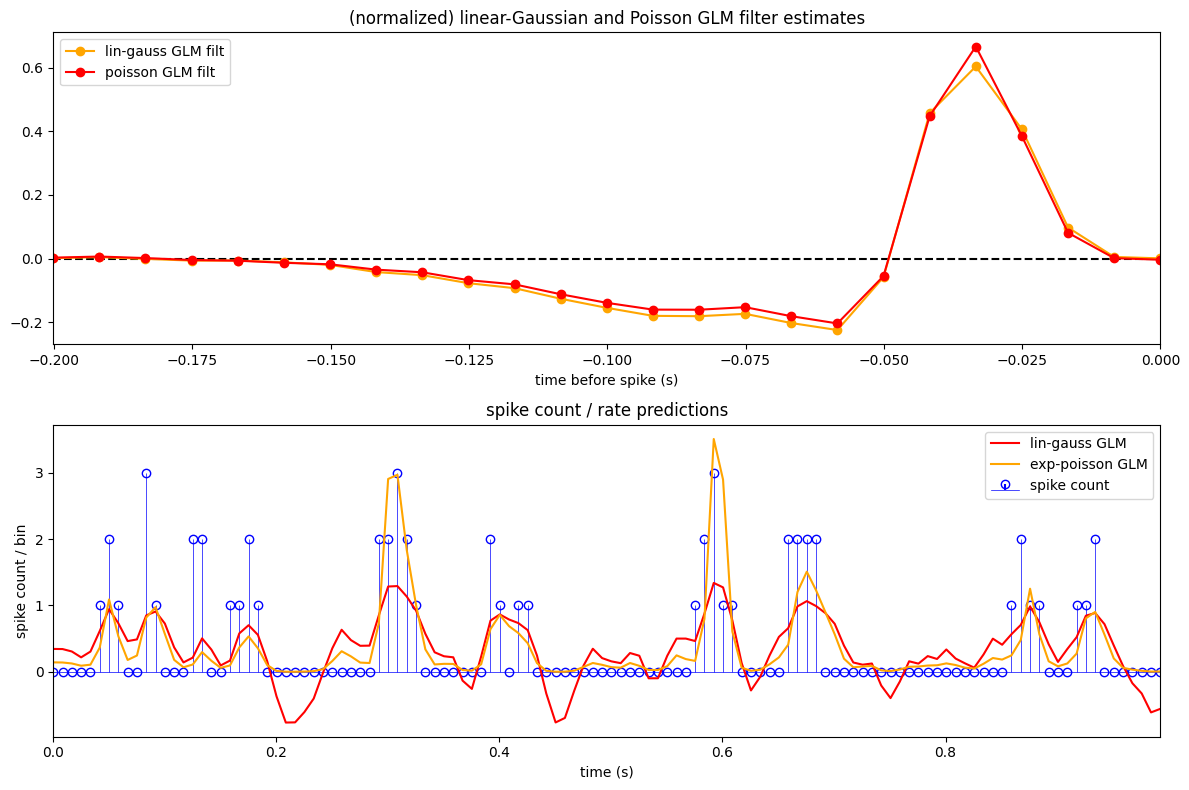

In [ ]:
plt.close()

fig, (ax1,ax2) = plt.subplots(2)
fig.set_size_inches(12,8)
ax1.plot(ttk,ttk*0, 'k--')
ax1.plot(ttk, wsta_offset/norm(wsta_offset), 'o-', label='lin-gauss GLM filt', c='orange')
ax1.plot(ttk, pGLM_filt/norm(pGLM_filt), 'o-', label='poisson GLM filt', c='r')
ax1.legend(loc = 'upper left')
ax1.set_title('(normalized) linear-Gaussian and Poisson GLM filter estimates')
ax1.set_xlabel('time before spike (s)')
ax1.set_xlim([ttk[0], ttk[-1]])

markerline,stemlines,baseline = plt.stem(ttplot,spikes_binned[iiplot], label="spike count", linefmt='b-', basefmt='b-')
plt.setp(markerline, 'markerfacecolor', 'none')
plt.setp(stemlines, color='b', linewidth=.5)
plt.setp(baseline, color='b', linewidth=.5)
ax2.plot(ttplot,sppred_lgGLM_offset[iiplot], label="lin-gauss GLM", c='r')
ax2.plot(ttplot,rate_pred_pGLM[iiplot], label="exp-poisson GLM", c='orange')
ax2.set_title('spike count / rate predictions')
ax2.set_ylabel('spike count / bin'); plt.xlabel('time (s)')
ax2.set_xlim([ttplot[0], ttplot[-1]])
ax2.legend(loc='upper right')
plt.tight_layout()

In [ ]:
# Compute R² for the Poisson GLM

mse_pGLM = np.mean((spikes_binned - rate_pred_pGLM)**2)
rss_pGLM = np.mean((spikes_binned - np.mean(spikes_binned))**2)
R2_pGLM = 1 - mse_pGLM / rss_pGLM

print('Training performance (R²): Poisson GLM = {:.3f}'.format(R2_pGLM))

Training performance (R²): Poisson GLM = 0.498


# **4. Simulating GLM Responses to a Repeated Stimulus**

The goal is to test how the model would respond to a repeated presentation of the same stimulus.

1. **Stimulus selection**
   A short segment of the original stimulus (first 60 time bins) is selected and repeated
   multiple times (e.g., 50 trials). This mimics presenting the same sensory input
   across different experimental repetitions.

2. **Predicted firing rate**
   For each time bin, the model predicts a mean firing rate:
       λ_t = exp(β₀ + X_t k)
   derived from the previously fitted parameters (β₀ = offset, k = stimulus filter).

3. **Spike generation**
   Given λ_t, spike counts are drawn from a Poisson distribution:
       y_{r,t} ~ Poisson(λ_t)
   for each repetition r. This step introduces stochastic variability across trials,
   reproducing the natural variability of neural firing.

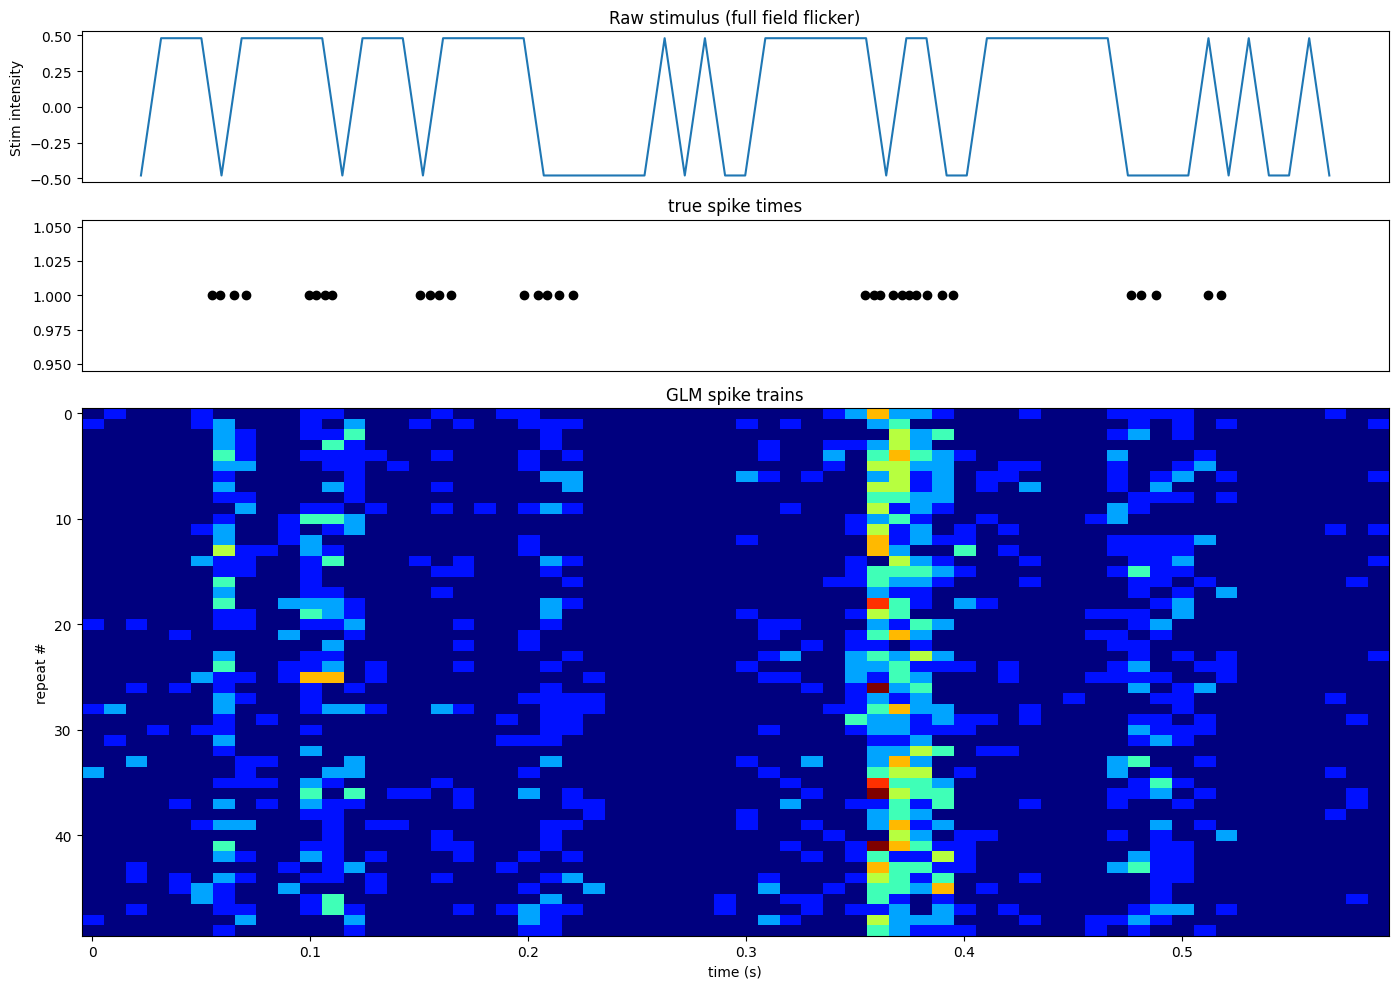

In [ ]:
# Simulate the response of the GLM to a repeated stimulus and make raster plots

iiplot = np.arange(60) # time bins of stimulus to use
ttplot = iiplot*dt_stim # time indices for these stimuli
stim_repeat = stim[iiplot] # repeat stimulus
num_repeats = 50;  # number of repeats
f_rate = np.exp(pGLM_const + design_mat[iiplot,:] @ pGLM_filt)# firing rate in each bin


# Plot stimulus and true spikes
plt.close()
fig = plt.figure(figsize=[14,10])
plt.subplot(10,1,(1,2))
plt.plot(ttplot,stim[iiplot])
plt.title('Raw stimulus (full field flicker)')
plt.ylabel('Stim intensity')
plt.xticks([])
plt.tight_layout()


plt.subplot(10,1,(3,4))
plt.plot(spike_times_plot, [1]*spike_times_plot.size, 'ko')
plt.xlim([ttplot[0],ttplot[-1]])
plt.title('true spike times')
plt.xticks([])

# Simulate spikes using draws from a Bernoulli (coin flipping) process
spike_counts = np.random.poisson(np.tile(f_rate.T,[num_repeats,1])) # sample spike counts for each time bin
plt.subplot(10,1,(5,10))
plt.imshow(spike_counts, cmap='jet', aspect='auto')
plt.ylabel('repeat #')
plt.xlabel('time (s)')
plt.title('GLM spike trains')
_,_ = plt.xticks(ticks=[0,10,20,30,40,50], labels=['0','0.1','0.2','0.3','0.4','0.5'])
plt.tight_layout()

# **5. Extending the GLM with Spike-History Effects**

In basic encoding models, spike generation depends only on the recent stimulus, and spikes are assumed to be conditionally independent given the stimulus. However, real neurons are state-dependent systems whose excitability is influenced by their own recent activity.

Neuronal firing exhibits temporal dependencies such as refractoriness and adaptation, which cannot be captured by stimulus-driven terms alone. To account for these intrinsic dynamics, we extend the Poisson GLM by including spike-history regressors, allowing the model to describe how recent spikes modulate current firing probability.

Spike-history design matrix shape: (144051, 25)


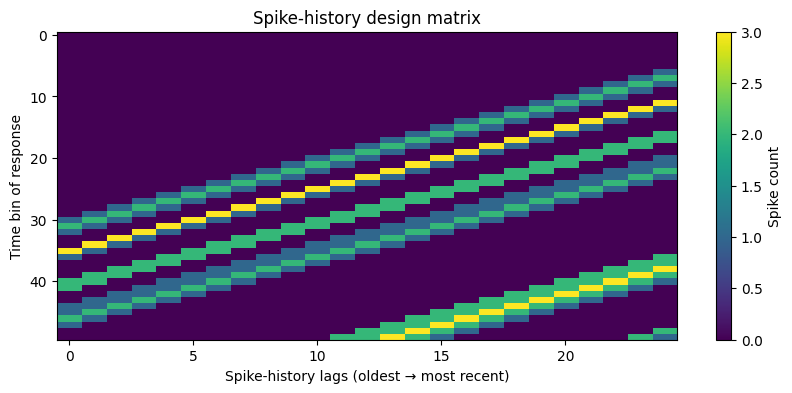

In [ ]:
# Spike-history design matrix
# Each row j contains the spike counts in the previous nhist bins
# Only past spikes are included (no leakage of y(j)).

nhist = 25                      # number of spike-history bins (~200 ms if dt ~ 8 ms)
num_time_bins = len(spikes_binned)

# Pad the spike train with zeros at the beginning
# Padding with nhist zeros ensures that y(j) is not included in the history
padded_spikes = np.hstack((np.zeros(nhist), spikes_binned))

# Initialize spike-history design matrix
spike_hist_mat = np.zeros((num_time_bins, nhist))

# Build the spike-history design matrix
for j in range(num_time_bins):
    spike_hist_mat[j] = padded_spikes[j:j+nhist]

print("Spike-history design matrix shape:", spike_hist_mat.shape)

# Visualize a small portion of the spike-history matrix
plt.figure(figsize=(10, 4))
plt.imshow(spike_hist_mat[:50], aspect='auto', interpolation='nearest')
plt.xlabel('Spike-history lags (oldest → most recent)')
plt.ylabel('Time bin of response')
plt.colorbar(label='Spike count')
plt.title('Spike-history design matrix')
plt.show()


### Interpretation

The spike-history design matrix shows how past spiking activity is encoded as regressors for the GLM. **Each row corresponds to a response time bin**, while **each column represents spike counts at increasing time lags in the past**, ordered from older to more recent history.

The **diagonal banded structure** reflects the temporal shift of past spikes across successive time bins: a spike occurring at a given time contributes to multiple future rows at increasing lags. This confirms that the design matrix encodes **only past activity**, preserving **causality** in the model.

Regions of higher intensity indicate **recent spikes with stronger influence on current firing probability**, consistent with **short-term temporal dependencies** such as refractoriness and adaptation. Overall, the spike-history regressors provide the model with access to intrinsic neuronal dynamics that cannot be captured by stimulus-driven terms alone.

## **5.1 Fitting a Poisson GLM with stimulus and spike-history**

So far, we have constructed two sets of regressors:

- a **stimulus design matrix**, capturing how past stimulus values influence neuronal firing;
- a **spike-history design matrix**, capturing how recent spikes modulate the probability of firing.

We now combine these regressors into a single **Poisson Generalized Linear Model (GLM)**. At each time bin, the spike count is modeled as a Poisson random variable whose mean firing rate depends on a linear combination of stimulus history and spike-history terms, passed through an exponential nonlinearity (log link).

By integrating both stimulus-driven and history-dependent effects, this extended GLM moves beyond the conditional independence assumption and enables the model to capture **intrinsic neuronal dynamics**, such as refractoriness and short-term adaptation, directly from data.



In [ ]:
# Number of time bins
num_time_bins = len(spikes_binned)

# Add an offset (bias) term
X_offset = np.ones((num_time_bins, 1))

# Full design matrix: [bias | stimulus history | spike-history]
X_full = np.hstack((X_offset, design_mat, spike_hist_mat))

print("Full design matrix shape:", X_full.shape)

# Fit Poisson GLM
glm_hist = sm.GLM(
    endog=spikes_binned,
    exog=X_full,
    family=sm.families.Poisson()
)

glm_hist_results = glm_hist.fit(maxiter=100, tol=1e-6)

print(glm_hist_results.summary())

Full design matrix shape: (144051, 51)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:               144051
Model:                            GLM   Df Residuals:                   144000
Model Family:                 Poisson   Df Model:                           50
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -72453.
Date:                Mon, 02 Feb 2026   Deviance:                       65439.
Time:                        17:36:07   Pearson chi2:                 1.83e+05
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4348
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        

### Interpretation of the fitted GLM parameters

The fitted Poisson GLM reveals distinct and interpretable contributions from stimulus history and spike-history terms. The intercept represents the **baseline firing rate** of the neuron and reflects its low spontaneous activity.

The stimulus-related coefficients form a **temporal filter** that describes how past stimulus values modulate the firing probability. The presence of strongly significant positive and negative coefficients at specific lags indicates that the neuron integrates the stimulus over time and responds preferentially to particular temporal features.

Crucially, the spike-history coefficients are predominantly **negative and highly significant**. This pattern reflects a strong **refractory effect**, whereby recent spikes substantially reduce the probability of firing in subsequent time bins. The gradual decrease in coefficient magnitude with increasing lag is consistent with a **progressive recovery of neuronal excitability** over time.

By including spike-history regressors, the GLM captures intrinsic neuronal dynamics that are not stimulus-driven. As a result, the extended model provides a more **biologically realistic description of spiking activity** and substantially improves the explanatory power of the encoding model.


## **5.2 Inspecting the spike-history filter**

After fitting the GLM with stimulus and spike-history terms, we analyze the learned spike-history filter, that describes how past spikes influence the probability of firing at the current time.

- A negative contribution at short time lags corresponds to refractoriness,
meaning that immediately after a spike the neuron is less likely to fire again
- Positive contributions at longer lags may indicate recovery or facilitatory effects.



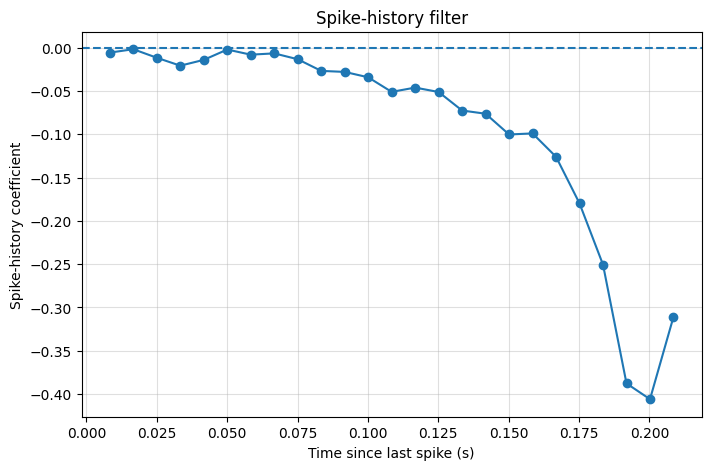

In [ ]:
# Extract and visualize the spike-history filter

# Number of parameters in each block
n_bias = 1
n_stim = design_mat.shape[1]
n_hist = spike_hist_mat.shape[1]

# Extract spike-history coefficients (ordered as oldest -> most recent lag)
spike_hist_filter = glm_hist_results.params[n_bias + n_stim : n_bias + n_stim + n_hist]

# Time axis (in seconds): lag 1 corresponds to dt_stim seconds before the current bin
time_hist = np.arange(1, n_hist + 1) * dt_stim

plt.figure(figsize=(8, 5))
plt.plot(time_hist, spike_hist_filter, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel('Time since last spike (s)')
plt.ylabel('Spike-history coefficient')
plt.title('Spike-history filter')
plt.grid(alpha=0.4)
plt.show()

### Interpretation of the spike-history filter

The learned spike-history filter shows a strong negative contribution at short time lags following a spike, indicating a pronounced **refractory effect**. Immediately after firing, the neuron’s probability of emitting another spike is substantially reduced, reflecting reduced excitability due to intrinsic biophysical mechanisms.

As the time since the last spike increases, the magnitude of the negative coefficients gradually decreases, indicating a **progressive recovery of excitability**. This temporal profile is consistent with short-term adaptation dynamics, where the neuron slowly returns toward its baseline firing state.

Overall, the shape of the spike-history filter demonstrates that recent spiking activity exerts a strong and time-dependent inhibitory influence on current firing probability. By capturing these history-dependent effects, the GLM provides a more biologically realistic description of neuronal spiking behavior beyond stimulus-driven responses.


## **5.3 Comparing GLM performance with and without spike-history**

After analyzing the learned spike-history filter, we now evaluate whether including spike-history terms leads to an actual improvement in predictive performance.

We compare two models:
- a **stimulus-only Poisson GLM**, based exclusively on stimulus history;
- a **stimulus + spike-history Poisson GLM**, which also accounts for intrinsic temporal dependencies.

Model performance is assessed by comparing the predicted firing rates and computing the coefficient of determination (R²) on the same dataset. This analysis quantifies the additional explanatory power provided by spike-history effects beyond stimulus-driven responses.

In [ ]:
# Compare GLM with and without spike-history


# Model WITHOUT spike-history (stimulus-only)
glm_stim = sm.GLM(
    endog=spikes_binned,
    exog=design_mat_offset,   # bias + stimulus
    family=sm.families.Poisson()
)
glm_stim_res = glm_stim.fit()

stim_const = glm_stim_res.params[0]
stim_filter = glm_stim_res.params[1:]

rate_pred_stim = np.exp(stim_const + design_mat @ stim_filter)

# Model WITH spike-history (stimulus + history)
design_mat_full = np.hstack([design_mat_offset, spike_hist_mat])

glm_hist = sm.GLM(
    endog=spikes_binned,
    exog=design_mat_full,
    family=sm.families.Poisson()
)
glm_hist_res = glm_hist.fit()

rate_pred_hist = np.exp(design_mat_full @ glm_hist_res.params)

# Compute R² for both models
rss = np.mean((spikes_binned - np.mean(spikes_binned))**2)

mse_stim = np.mean((spikes_binned - rate_pred_stim)**2)
mse_hist = np.mean((spikes_binned - rate_pred_hist)**2)

R2_stim = 1 - mse_stim / rss
R2_hist = 1 - mse_hist / rss

print(f"R² (stimulus-only GLM): {R2_stim:.3f}")
print(f"R² (stimulus + spike-history GLM): {R2_hist:.3f}")


R² (stimulus-only GLM): 0.498
R² (stimulus + spike-history GLM): 0.544


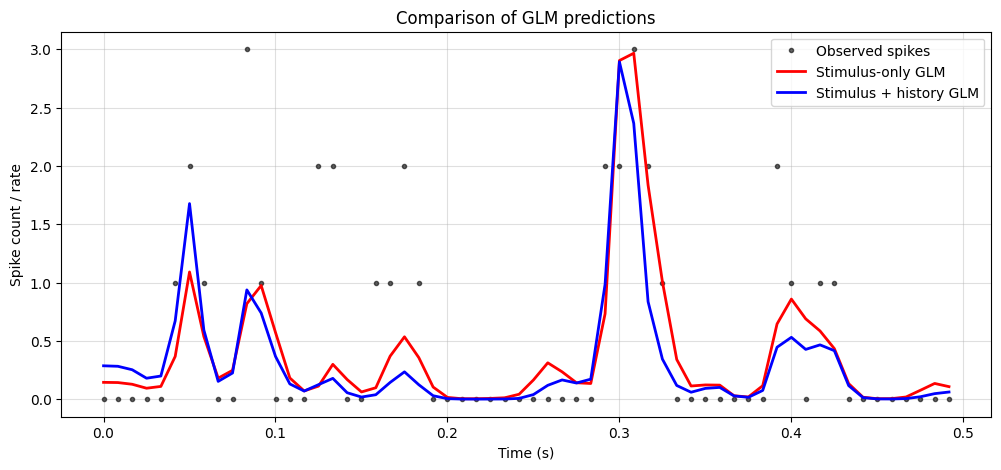

In [ ]:
# Visual comparison of predicted firing rates
plt.figure(figsize=(12, 5))

plt.plot(ttplot, spikes_binned[iiplot], 'k.', label='Observed spikes', alpha=0.6)
plt.plot(ttplot, rate_pred_stim[iiplot], 'r', linewidth=2, label='Stimulus-only GLM')
plt.plot(ttplot, rate_pred_hist[iiplot], 'b', linewidth=2, label='Stimulus + history GLM')

plt.xlabel('Time (s)')
plt.ylabel('Spike count / rate')
plt.title('Comparison of GLM predictions')
plt.legend()
plt.grid(alpha=0.4)
plt.show()


### **Comparison of GLM predictions**

The GLM including spike-history terms achieves a higher predictive accuracy (R² = 0.544) than the stimulus-only model (R² = 0.498), indicating a clear improvement when intrinsic spiking dynamics are taken into account.

Although the increase in R² is moderate, it is consistent with the expected role of spike-history effects, which primarily influence firing probability immediately following spikes rather than stimulus-locked responses. This difference is reflected in the predicted firing rates: the stimulus-only model tends to overestimate firing shortly after spikes, whereas the spike-history model effectively suppresses firing during these periods, capturing refractory dynamics.

Overall, these results show that spike-history provides complementary information to the stimulus and leads to a more accurate and biologically plausible encoding model.



### **5.4 Spike-history window length analysis**

In the previous sections we showed that adding spike-history regressors improves the GLM.
Here we further investigate on which time scale spike-history contributes to prediction.

We repeat the fitting of the stimulus + spike-history GLM for different spike-history window lengths (nhist),
and we measure model performance (R²) for each choice.
This allows us to quantify how much recent spiking activity influences firing probability and to identify
the temporal extent of refractory/adaptive effects captured by the model.

nhist =   5  ->  R² = 0.4958
nhist =  10  ->  R² = 0.5005
nhist =  20  ->  R² = 0.5015
nhist =  40  ->  R² = 0.5023
nhist =  60  ->  R² = 0.5033


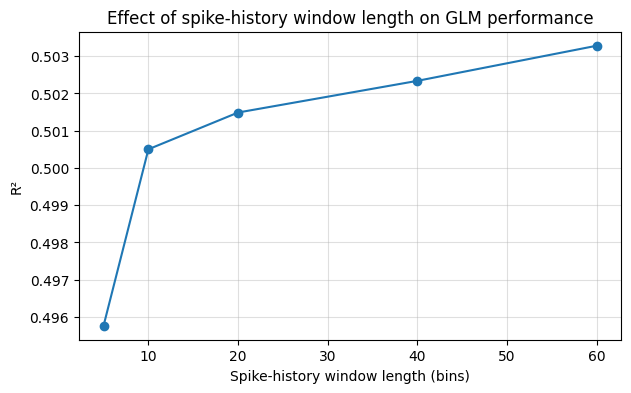

In [ ]:
# Spike-history window length analysis
nhist_list = [5, 10, 20, 40, 60]
R2_list = []
hist_filters = {}

# Baseline variance term for R²
rss = np.mean((spikes_binned - np.mean(spikes_binned))**2)

for nhist in nhist_list:

    # build spike-history design matrix for this nhist
    padded_spikes = np.hstack((np.zeros(nhist-1), spikes_binned))
    spike_hist_mat_tmp = np.zeros((num_time_bins, nhist))

    for t in range(num_time_bins):
        spike_hist_mat_tmp[t, :] = padded_spikes[t:t+nhist]

    # full design matrix: [bias + stimulus | spike-history]
    X_full_tmp = np.hstack([design_mat_offset, spike_hist_mat_tmp])

    #  fit Poisson GLM
    glm_tmp = sm.GLM(endog=spikes_binned, exog=X_full_tmp, family=sm.families.Poisson())
    res_tmp = glm_tmp.fit(maxiter=100, tol=1e-6)

    # predicted rate and R²
    rate_tmp = np.exp(X_full_tmp @ res_tmp.params)
    mse_tmp = np.mean((spikes_binned - rate_tmp)**2)
    R2_tmp = 1 - mse_tmp / rss

    R2_list.append(R2_tmp)

    # store spike-history filter for later visualization
    hist_filters[nhist] = res_tmp.params[design_mat_offset.shape[1]:]  # take last nhist params

    print(f"nhist = {nhist:>3d}  ->  R² = {R2_tmp:.4f}")

# Plot performance as a function of nhist
plt.figure(figsize=(7,4))
plt.plot(nhist_list, R2_list, 'o-')
plt.xlabel('Spike-history window length (bins)')
plt.ylabel('R²')
plt.title('Effect of spike-history window length on GLM performance')
plt.grid(alpha=0.4)
plt.show()

The performance curve shows how predictive accuracy changes as the spike-history window length increases.
A rapid improvement at short windows suggests that very recent spikes (tens of milliseconds) carry most of the information,
consistent with refractory dynamics.
If performance saturates beyond a certain nhist, it indicates that longer spike-history contributions become negligible.

We also visualize the spike-history filters learned for different nhist values to inspect how the refractory profile
and its temporal extent change with the chosen history window.

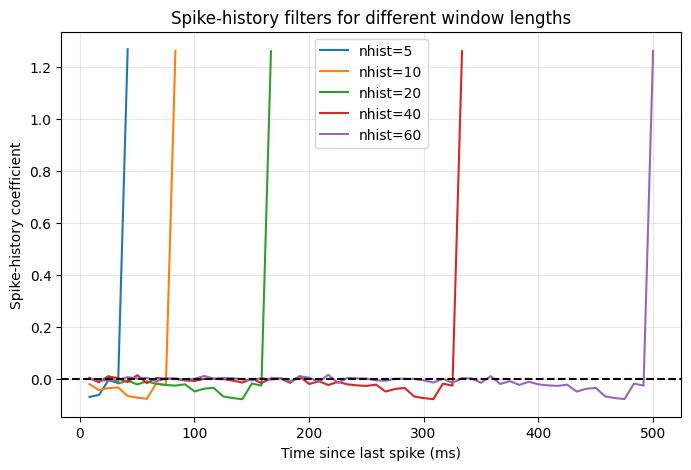

In [ ]:
# Visualize spike-history filters for different nhist
plt.figure(figsize=(8,5))

for nhist in nhist_list:
    h = hist_filters[nhist]
    t_hist = np.arange(1, len(h)+1) * dt_stim * 1000  # ms
    plt.plot(t_hist, h, label=f'nhist={nhist}')

plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Time since last spike (ms)')
plt.ylabel('Spike-history coefficient')
plt.title('Spike-history filters for different window lengths')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Across different window lengths, the short-lag negative coefficients are consistently observed,
indicating a robust refractory effect.
Longer windows mainly extend the filter tail, but do not necessarily improve prediction once the relevant
physiological time scale has been captured.

### **5.5 Ablation study: stimulus vs spike-history contributions**

To better understand the role of spike-history terms, we perform an ablation study.
We compare three different models:

1. a stimulus-only GLM;
2. a spike-history-only GLM;
3. a combined stimulus + spike-history GLM.

By comparing predictive performance across these models, we assess whether spike-history
captures information that is complementary to the stimulus, rather than redundant.

In [ ]:
nhist = 25

# build spike-history matrix
padded_spikes = np.hstack((np.zeros(nhist-1), spikes_binned))
spike_hist_mat = np.zeros((num_time_bins, nhist))

for t in range(num_time_bins):
    spike_hist_mat[t, :] = padded_spikes[t:t+nhist]


# 1) Stimulus-only GLM (baseline)
glm_stim = sm.GLM(endog=spikes_binned,
                  exog=design_mat_offset,
                  family=sm.families.Poisson())
res_stim = glm_stim.fit(maxiter=100, tol=1e-6)

rate_stim = np.exp(design_mat_offset @ res_stim.params)

# 2) Spike-history-only GLM
X_hist_only = np.hstack([np.ones((num_time_bins,1)), spike_hist_mat])

glm_hist = sm.GLM(endog=spikes_binned,
                  exog=X_hist_only,
                  family=sm.families.Poisson())
res_hist = glm_hist.fit(maxiter=100, tol=1e-6)

rate_hist = np.exp(X_hist_only @ res_hist.params)


# 3) Stimulus + spike-history GLM
X_full = np.hstack([design_mat_offset, spike_hist_mat])

glm_full = sm.GLM(endog=spikes_binned,
                  exog=X_full,
                  family=sm.families.Poisson())
res_full = glm_full.fit(maxiter=100, tol=1e-6)

rate_full = np.exp(X_full @ res_full.params)

# Compute R² for each model
rss = np.mean((spikes_binned - np.mean(spikes_binned))**2)

R2_stim = 1 - np.mean((spikes_binned - rate_stim)**2) / rss
R2_hist = 1 - np.mean((spikes_binned - rate_hist)**2) / rss
R2_full = 1 - np.mean((spikes_binned - rate_full)**2) / rss

print(f"R² stimulus-only      : {R2_stim:.4f}")
print(f"R² spike-history-only : {R2_hist:.4f}")
print(f"R² stimulus + history : {R2_full:.4f}")

R² stimulus-only      : 0.4978
R² spike-history-only : 0.4137
R² stimulus + history : 0.5018


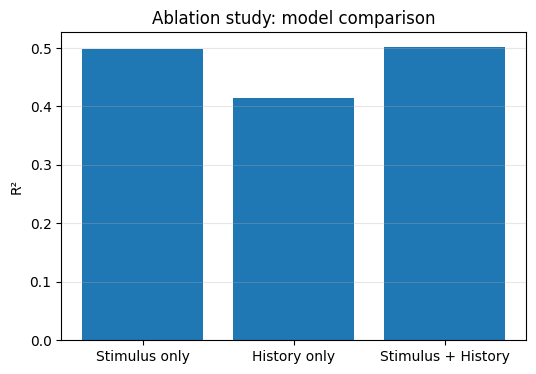

In [ ]:
# Plot R² comparison

labels = ['Stimulus only', 'History only', 'Stimulus + History']
R2_vals = [R2_stim, R2_hist, R2_full]

plt.figure(figsize=(6,4))
plt.bar(labels, R2_vals)
plt.ylabel('R²')
plt.title('Ablation study: model comparison')
plt.grid(axis='y', alpha=0.3)
plt.show()

The stimulus-only model captures the main stimulus-driven modulation of firing rate,
while the spike-history-only model explains only a limited fraction of the variance,
reflecting intrinsic firing dynamics.

The combined model consistently achieves the highest performance, indicating that
stimulus and spike-history provide complementary information about neuronal firing.

### **5.6 Generalization across neurons**

So far, the analysis has focused on a single neuron. To strengthen the conclusions and avoid over-interpreting a single recording, we now assess whether the observed effects generalize across multiple neurons.

We repeat the same modeling pipeline for several recorded neurons, using the same stimulus representation and temporal binning. For each neuron, we fit two models:
1. a stimulus-only Poisson GLM;
2. a stimulus + spike-history Poisson GLM, using a fixed history window length (`nhist`) selected from the previous analysis.

Model performance is quantified using the same R² metric adopted throughout the notebook.

We first construct binned spike trains for each neuron using identical time bins, ensuring comparability across recordings. We then fit both models independently for each neuron and compare their predictive performance, reporting both neuron-wise results and summary statistics across the population.


Neuron 0 -> R² stim-only = 0.3520, R² stim+hist = 0.3843
Neuron 1 -> R² stim-only = 0.2669, R² stim+hist = 0.3255
Neuron 2 -> R² stim-only = 0.4978, R² stim+hist = 0.5443


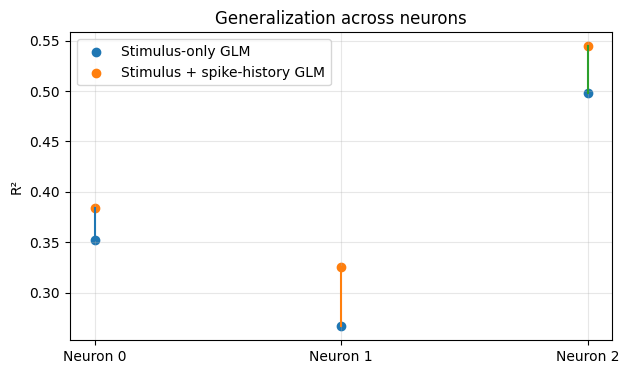

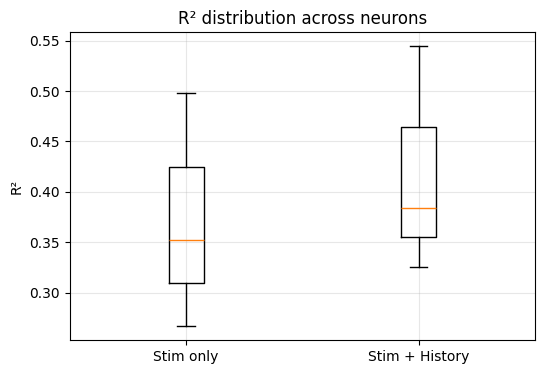

Stim-only:      mean R² = 0.3722 ± 0.0954
Stim+history:   mean R² = 0.4180 ± 0.0925
ΔR²:            mean ΔR² = 0.0458 ± 0.0107


In [ ]:
# Generalization across neurons (stim-only vs stim+history)

cell_indices = [0, 1, 2]   # choose 3 neurons
nhist = 25                 # fixed nhist

T = design_mat_offset.shape[0]      # reference length
bin_edges = np.arange(T + 1) * dt_stim

def build_spike_history_matrix_lagged(spikes_binned, nhist):
    y = np.asarray(spikes_binned)
    Tloc = len(y)
    H = np.zeros((Tloc, nhist))
    for k in range(1, nhist+1):
        H[k:, k-1] = y[:-k]
    return H

R2_stim_all, R2_full_all = [], []
neuron_labels = []

for ci in cell_indices:
    # spike times for neuron ci (replace with your variable)
    spike_times_ci = np.array(all_spike_times[ci]).squeeze()

    # binning
    spikes_binned_ci, _ = np.histogram(spike_times_ci, bins=bin_edges)

    # ensure same length as design matrix
    spikes_binned_ci = spikes_binned_ci[:T]

    # build lagged history matrix
    H_ci = build_spike_history_matrix_lagged(spikes_binned_ci, nhist)

    # 1) stim-only
    res_stim = sm.GLM(spikes_binned_ci, design_mat_offset, family=sm.families.Poisson()).fit(maxiter=100, tol=1e-6)
    rate_stim = np.exp(design_mat_offset @ res_stim.params)

    # 2) stim+history
    X_full = np.hstack([design_mat_offset, H_ci])
    res_full = sm.GLM(spikes_binned_ci, X_full, family=sm.families.Poisson()).fit(maxiter=100, tol=1e-6)
    rate_full = np.exp(X_full @ res_full.params)

    # R²
    rss = np.mean((spikes_binned_ci - np.mean(spikes_binned_ci))**2)
    R2_stim = 1 - np.mean((spikes_binned_ci - rate_stim)**2) / rss
    R2_full = 1 - np.mean((spikes_binned_ci - rate_full)**2) / rss

    R2_stim_all.append(R2_stim)
    R2_full_all.append(R2_full)
    neuron_labels.append(f"Neuron {ci}")

    print(f"Neuron {ci} -> R² stim-only = {R2_stim:.4f}, R² stim+hist = {R2_full:.4f}")

# paired plot
x = np.arange(len(neuron_labels))
plt.figure(figsize=(7,4))
plt.scatter(x, R2_stim_all, label='Stimulus-only GLM')
plt.scatter(x, R2_full_all, label='Stimulus + spike-history GLM')
for i in range(len(x)):
    plt.plot([x[i], x[i]], [R2_stim_all[i], R2_full_all[i]])
plt.xticks(x, neuron_labels)
plt.ylabel('R²')
plt.title('Generalization across neurons')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# boxplot
plt.figure(figsize=(6,4))
plt.boxplot([R2_stim_all, R2_full_all], tick_labels=['Stim only', 'Stim + History'])
plt.ylabel('R²')
plt.title('R² distribution across neurons')
plt.grid(alpha=0.3)
plt.show()

# summary
delta = np.array(R2_full_all) - np.array(R2_stim_all)
print(f"Stim-only:      mean R² = {np.mean(R2_stim_all):.4f} ± {np.std(R2_stim_all):.4f}")
print(f"Stim+history:   mean R² = {np.mean(R2_full_all):.4f} ± {np.std(R2_full_all):.4f}")
print(f"ΔR²:            mean ΔR² = {np.mean(delta):.4f} ± {np.std(delta):.4f}")


1. The **paired comparison plot** shows that, for each tested neuron, the stimulus + spike-history GLM consistently achieves higher R² than the stimulus-only model. The vertical distance between paired points represents the gain in predictive performance due to the inclusion of spike-history terms, which is positive for all neurons.

2. The **boxplot** summarizes the distribution of R² values across neurons for the two models. Including spike-history terms shifts the distribution toward higher R² values, indicating an overall improvement in predictive performance. Importantly, the variability across neurons remains comparable between the two models, suggesting that the improvement is robust and not driven by a single outlier.

The mean increase in R² (ΔR² ≈ 0.045) is moderate but consistent, which is expected given that spike-history terms capture intrinsic temporal dynamics such as refractoriness and adaptation, rather than the main stimulus-driven component of the response.


### **5.7 Simulating spike trains from the fitted GLMs**

After comparing predictive performance, we now use the fitted GLMs to simulate spike trains.
The goal is to assess how including spike-history terms changes the temporal structure of
the generated activity, beyond average firing rates.

We simulate spike trains from:
1. a stimulus-only Poisson GLM (spikes are independent across time bins given the stimulus);
2. a stimulus + spike-history GLM (history-dependent point process).

This allows us to compare not only mean responses, but also spike timing variability and
refractory effects in the generated spike trains.


In [ ]:
# Simulate spike trains from the fitted GLMs (stimulus-only vs stim+history)

np.random.seed(0)
T = num_time_bins
dt = dt_stim

# 1) Stimulus-only simulation (Poisson)
rate_stim = rate_pred_stim  # predicted rate (spikes/second)
spikes_sim_stim = np.random.poisson(rate_stim * dt)  # expected spikes per bin

# 2) History-dependent simulation (Poisson, sequential)
spikes_sim_hist = np.zeros(T)

for t in range(T):
    # stimulus contribution to linear predictor
    stim_term = design_mat[t] @ stim_filter + stim_const

    # spike-history contribution computed from simulated spikes (causal)
    if t >= nhist:
        hist_vec = spikes_sim_hist[t-nhist:t][::-1]   # length = nhist
        hist_term = hist_vec @ spike_hist_filter
    else:
        hist_term = 0.0

    # conditional intensity (spikes/second)
    rate_t = np.exp(stim_term + hist_term)

    # sample spikes in this bin (expected spikes per bin = rate_t * dt)
    spikes_sim_hist[t] = np.random.poisson(rate_t * dt)

print("Simulation completed.")

Simulation completed.


## **5.8 Raster plots and spike train statistics**

We compare spike trains simulated from two fitted models: a stimulus-only Poisson GLM and a stimulus + spike-history Poisson GLM.

Spike trains are generated from the model-predicted firing rates under the same stimulus, allowing a direct comparison of spike timing.

Raster plots provide a qualitative visualization of temporal structure, while interspike interval (ISI) statistics and the coefficient of variation (CV) quantify spike timing irregularity.

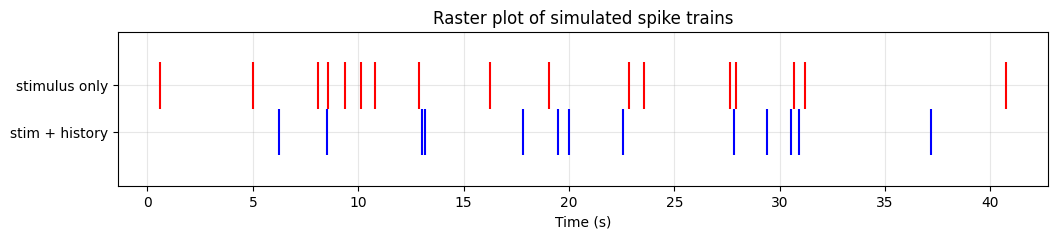

In [ ]:
start = 0
L = 5000
idx = np.arange(start, start + L)
tplot = idx * dt

plt.figure(figsize=(12,2))

# stimulus-only spikes
plt.eventplot(
    tplot[spikes_sim_stim[idx] > 0],
    lineoffsets=1,
    colors='r'
)

# stim + history spikes
plt.eventplot(
    tplot[spikes_sim_hist[idx] > 0],
    lineoffsets=0,
    colors='b'
)

plt.yticks([0,1], ['stim + history', 'stimulus only'])
plt.xlabel('Time (s)')
plt.title('Raster plot of simulated spike trains')
plt.grid(alpha=0.3)
plt.show()

The raster plot shows simulated spike trains generated by the two models.

The stimulus-only GLM produces spikes that are nearly independent across time bins.
In contrast, the model including spike-history terms exhibits fewer closely spaced spikes, reflecting refractoriness learned from the data.

### **Comparison of simulated spike trains**

The figure shows spike trains simulated from two fitted models driven by the same stimulus:
a stimulus-only Poisson GLM and a stimulus + spike-history GLM.

The stimulus-only model generates spikes independently across time bins.
As a result, spikes can occur in rapid succession and high-count events may appear,
reflecting the lack of intrinsic temporal constraints.

In contrast, the model including spike-history terms produces more structured spike trains.
Immediately after a spike, the firing probability is reduced, leading to fewer closely spaced spikes.
This behavior reflects refractory effects learned from the data.

Although both models respond to the same stimulus, the inclusion of spike-history
strongly shapes the temporal organization of spikes, producing activity patterns
that are more consistent with known physiological properties of neurons.


In [ ]:
# Interspike interval statistics
def compute_isi(spike_counts, dt):
    spike_times = np.where(spike_counts > 0)[0] * dt
    return np.diff(spike_times)

isi_obs  = compute_isi(spikes_binned, dt)
isi_stim = compute_isi(spikes_sim_stim, dt)
isi_hist = compute_isi(spikes_sim_hist, dt)

def CV(isi):
    return np.std(isi) / np.mean(isi)

print(f"CV observed: {CV(isi_obs):.2f}")
print(f"CV stim-only GLM: {CV(isi_stim):.2f}")
print(f"CV stim + history GLM: {CV(isi_hist):.2f}")


CV observed: 1.07
CV stim-only GLM: 0.98
CV stim + history GLM: 1.01


### **Interspike interval (ISI) statistics**

The analysis of interspike interval (ISI) statistics confirms the qualitative differences observed in the raster plots. The observed spike train shows a CV of approximately 1.07, indicating moderately irregular spiking. The stimulus-only GLM produces spike trains with a CV close to 1 (0.98), consistent with Poisson-like, temporally independent spiking. In contrast, the GLM including spike-history terms yields a slightly higher regularity (CV ≈ 1.01), consistent with weak refractory effects that reduce the occurrence of very short interspike intervals.




# **Conclusion and perspectives**

In this project, we developed an extended Poisson Generalized Linear Model that integrates both stimulus history and spike-history regressors to model neuronal spiking activity. By relaxing the conditional independence assumption, the model captures intrinsic temporal dependencies such as refractoriness and recovery, resulting in improved predictive performance and more realistic spike train statistics compared to stimulus-only models.

Beyond fitting firing rates, the model was used to simulate spike trains and analyze their statistical properties, showing that history-dependent GLMs better reproduce temporal structure, variability, and refractory effects observed in real neuronal data. This demonstrates how incorporating spike-history terms moves the model closer to a biologically grounded point-process description of neural activity.

The proposed framework is computationally efficient, modular, and easily extensible. It can be applied to longer recordings, multiple neurons, or enriched with additional covariates such as behavioral variables or latent states. Overall, this work provides a principled and flexible approach for studying the interplay between stimulus-driven encoding and intrinsic neuronal dynamics, offering a solid basis for further extensions such as regularization, cross-validation, or coupled population GLMs.
